# 3: Modeling

Build and evaluate models to predict hourly CitiBike departures per station. Four models compares against a mean-prediction baseline using a chronological train/test split of April and May for training, June for testing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import geopandas as gpd
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

## 3.1: Setup

In [ ]:
df_model = pd.read_csv('../data/processed/hourly_merged.csv', parse_dates=['start_hour'])
station_lookup = pd.read_csv('../data/processed/station_lookup.csv')

COLORS = {
	'primary': '#2563EB',
	'secondary': '#F59E0B', 
	'accent': '#10B981',
	'muted': '#94A3B8'
}

## 3.2: Feature Engineering

16 features constructed for modeling:
- Time Features: hour of day, day of week, month, is_weekend, is_rush_hour
- Cyclical Encodings: sine-cosine encoding of hour and day of week to correct wraparound problem where hour 23/0, day 6/0 are numerically adjacent but temporally adjacent
- Weather: temperature, precipitation, wind speed
- Geographic: borough membership (one-hot encoded)
- School Proximity: binary flag from station lookup

In [ ]:
df = df_model.merge(
     station_lookup[['start_station_id', 'near_school']],
     on='start_station_id', how='left'
)

# one hot encode
df = pd.get_dummies(df, columns=['boroname'], prefix='boro', drop_first=True)

# cyclical encode for periodic data
df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# define feature columns
boro_cols = [c for c in df.columns if c.startswith('boro_')]

feature_cols = [
     'hour_of_day', 'day_of_week', 'month', 'is_weekend', 'is_rush_hour',
     'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'HourlyDryBulbTemperature',
     'HourlyPrecipitation', 'HourlyWindSpeed', 'near_school'
] + boro_cols

target_col = 'ride_count'

# drop nulls in features
df_clean = df[feature_cols + [target_col, 'start_hour', 'start_station_id', 'ntaname']].dropna()
df_clean[boro_cols] = df[boro_cols].astype(int)

print(f"Modeling dataset shape: {df_clean.shape}")
print(f"Features: {len(feature_cols)}")
print([c for c in df.columns if c.startswith('boro_')])

Modeling dataset shape: (1762912, 20)
Features: 16
['boro_Brooklyn', 'boro_Manhattan', 'boro_Queens']
                 ntaname  boro_Brooklyn  boro_Manhattan  boro_Queens
0     Sunset Park (West)           True           False        False
1             Kensington           True           False        False
2             Kensington           True           False        False
3     Sunset Park (West)           True           False        False
4  East Flatbush-Erasmus           True           False        False


## 3.3: Chronological Train/Test Split

Split on April-May (1.18M rows), test on June (582K rows). Train mean ridership is slightly higher than test mean, reflecting the previous observation of June ridership counts flattening.

In [ ]:
train = df_clean[df_clean['start_hour'] < '2024-06-01']
test = df_clean[df_clean['start_hour'] >= '2024-06-01']

X_train = train[feature_cols]
y_train = train[target_col]
X_test = test[feature_cols]
y_test = test[target_col]

print(f"Train size: {len(train):,} rows ({train['start_hour'].min().date()} to {train['start_hour'].max().date()})")
print(f"Test size: {len(test):,} rows ({test['start_hour'].min().date()} to {test['start_hour'].max().date()})")
print(f"Train mean ride_count: {y_train.mean():.3f}")
print(f"Test mean ride_count: {y_test.mean():.3f}")

Train size: 1,180,227 rows (2024-04-01 to 2024-05-31)
Test size: 582,685 rows (2024-06-02 to 2024-06-30)
Train mean ride_count: 3.138
Test mean ride_count: 2.889
(1180227, 16)
(582685, 16)
0
0


## 3.4: Baseline Model

Predicts the mean ride count for every observation as a baseline for model performance down the line

In [ ]:
baseline_pred = np.full(len(y_test), y_train.mean())
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)
baseline_mae = mean_absolute_error(y_test, baseline_pred)

print(f"Baseline (mean prediction):")
print(f"RMSE: {baseline_rmse:.4f}")
print(f"R2: {baseline_r2:.4f}")
print(f"MAE: {baseline_mae:.4f}")

Baseline (mean prediction):
RMSE: 2.9799
R2: -0.0071
MAE: 2.0842


## 3.5: Model Training and Evaluation

Four models evaluated: Linear Regression, Ridge, LASSO, and Random Forest. Random Forest achieves the best performance, with 10.5% RMSE improvement over baseline. R2 = 0.19 reflects noise in hourly station-level ridership data. Individual features show weak pairwise correlations with ride_count, consisent once again with demand being driven by a combination of factors

In [ ]:
# main worker function for model evaluations
def eval_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    print(f"{name:25s} RMSE: {rmse:.4f} R2: {r2:.4f} MAE: {mae:.4f}")
    return model, preds, {'name': name, 'rmse': rmse, 'r2': r2, 'mae': mae}

models = {}
predictions = {}
results = []

# linear regression
lr, lr_preds, lr_stats = eval_model(
    'Linear Regression',
    LinearRegression(),
    X_train, y_train, X_test, y_test
)
models['Linear Regression'] = lr
predictions['Linear Regression'] = lr_preds
results.append(lr_stats)

# ridge
ridge, ridge_preds, ridge_stats = eval_model(
    'Ridge Regression',
    Ridge(alpha=1.0),
    X_train, y_train, X_test, y_test
)
models['Ridge Regression'] = ridge
predictions['Ridge Regression'] = ridge_preds
results.append(ridge_stats)

# lasso
lasso, lasso_preds, lasso_stats = eval_model(
    'Lasso Regression',
    Lasso(alpha=0.01),
    X_train, y_train, X_test, y_test
)
models['Lasso Regression'] = lasso
predictions['Lasso Regression'] = lasso_preds
results.append(lasso_stats)

# random forest
# max_depth of 10 to prevent overfitting on noisy hourly data
rf, rf_preds, rf_stats = eval_model(
    'Random Forest',
    RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    X_train, y_train, X_test, y_test
)
models['Random Forest'] = rf
predictions['Random Forest'] = rf_preds
results.append(rf_stats)

# add baseline to results to compare
results.insert(0, {'name': 'Baseline (mean)',
                'rmse': baseline_rmse,
                'r2': baseline_r2,
                'mae': baseline_mae})

results_df = pd.DataFrame(results)
print(f"Model Comparison:\n{results_df.to_string(index=False)}")

Linear Regression         RMSE: 2.7309 R2: 0.1542 MAE: 1.8425
Ridge Regression          RMSE: 2.7309 R2: 0.1542 MAE: 1.8425
Lasso Regression          RMSE: 2.7307 R2: 0.1543 MAE: 1.8482
Random Forest             RMSE: 2.6658 R2: 0.1940 MAE: 1.7610
Model Comparison:
             name     rmse        r2      mae
  Baseline (mean) 2.979859 -0.007053 2.084163
Linear Regression 2.730913  0.154182 1.842525
 Ridge Regression 2.730910  0.154184 1.842519
 Lasso Regression 2.730719  0.154303 1.848248
    Random Forest 2.665846  0.194007 1.761022


## 3.6: Model Comparison Plot

Comparison of model performance. The three linear models share similar values across all three metrics, showing that regularization doesn't help much in this instance. Random forest does noticeably better than the other three models, and shows decent improvement over baseline

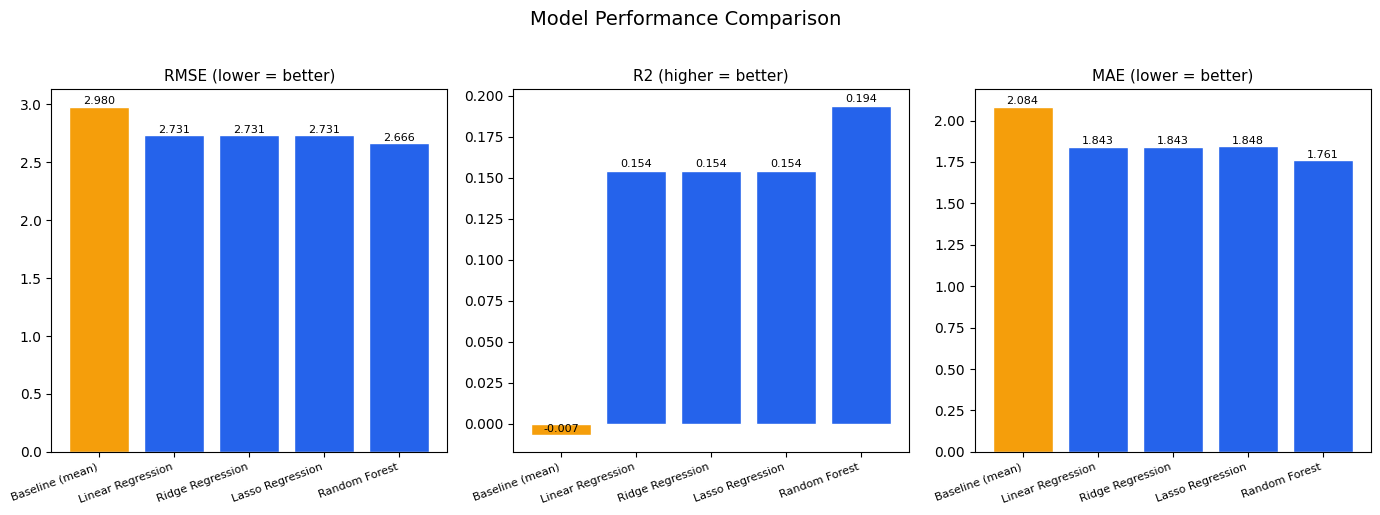

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ['rmse', 'r2', 'mae']
titles = ['RMSE (lower = better)', 'R2 (higher = better)', 'MAE (lower = better)']
colors = [COLORS['secondary'] if r['name'] == 'Baseline (mean)' else COLORS['primary'] for _, r in results_df.iterrows()]

for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.bar(results_df['name'], results_df[metric], color=colors, edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_xticklabels(results_df['name'], rotation=20, ha='right', fontsize=8)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{val:.3f}", ha='center', va='bottom', fontsize=8)

plt.suptitle('Model Performance Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/model/model_comparison.png', bbox_inches='tight')
plt.show()

## 3.7: Predicted vs Actual

Actual vs predicted ridership compared across demand bins. Model handles low and moderate demand well but underpredicts high-demand periods. At actual ridership of 20-25 rides per hour, the model predicts less than 10. Peak demand events vary on a month to month basis, which might be the cause of underprediction in the model's results.

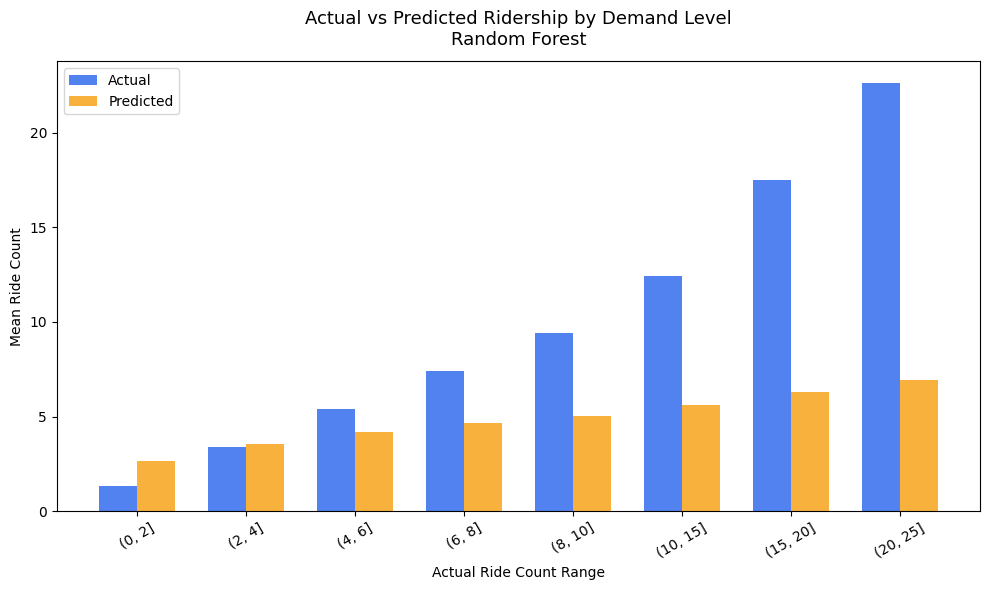

In [ ]:
best_preds = rf_preds
test_with_preds = test.copy()
test_with_preds['predicted'] = best_preds

# Represent the average actual vs predicted ride count at specific interval
bins = [0, 2, 4, 6, 8, 10, 15, 20, 25]
test_with_preds['actual_bin'] = pd.cut(test_with_preds['ride_count'], bins=bins)

binned = (test_with_preds.groupby('actual_bin', observed=True)
        .agg(mean_actual=('ride_count', 'mean'),
            mean_predicted=('predicted', 'mean'),
            count=('ride_count', 'count'))
        .reset_index())

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(binned))
width = 0.35

ax.bar([i - width/2 for i in x], binned['mean_actual'], width, label='Actual', color=COLORS['primary'], alpha=0.8)
ax.bar([i + width/2 for i in x], binned['mean_predicted'], width, label='Predicted', color=COLORS['secondary'], alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([str(b) for b in binned['actual_bin']], rotation=30)
ax.set_xlabel('Actual Ride Count Range')
ax.set_ylabel('Mean Ride Count')
ax.set_title('Actual vs Predicted Ridership by Demand Level\nRandom Forest', fontsize=13, pad=12)

ax.legend()
plt.tight_layout()
plt.savefig('../figures/model/predicted_vs_actual.png', bbox_inches='tight')
plt.show()

## 3.8: Residuals Over Time

Daily mean residuals across the June test period. Residuals drift negative past the midpoint of June, where the model increasingly overpredicts as the month progresses. In-line with late-June temperatures reaching into the high-80s, exceeding the training data range. The model overpredicts when the ridership plateaus in June, as seen in the time series from the EDA section. A printout of the weather pattern in the second half of June explains this phenomenon perfectly

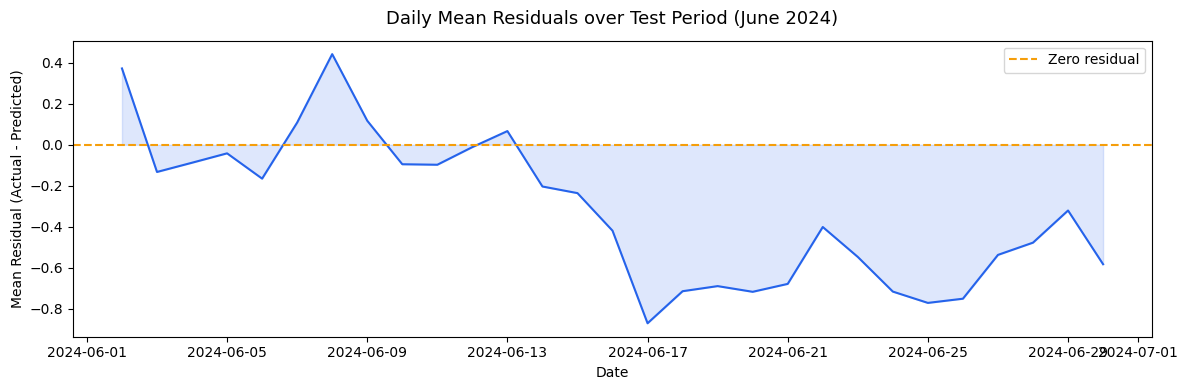

start_hour
2024-06-11    68.099100
2024-06-12    70.033577
2024-06-13    76.260801
2024-06-14    75.310150
2024-06-15    74.764126
2024-06-16    69.479150
2024-06-17    76.756655
2024-06-18    79.955870
2024-06-19    79.821233
2024-06-20    83.145586
2024-06-21    84.615985
2024-06-22    81.493350
2024-06-23    84.861088
2024-06-24    75.383776
2024-06-25    82.617880
2024-06-26    82.563354
2024-06-27    76.609019
2024-06-28    70.680621
2024-06-29    74.409237
2024-06-30    76.828821
Name: HourlyDryBulbTemperature, dtype: float64


In [ ]:
test_with_preds['residual'] = y_test.values - best_preds

daily_residuals = (test_with_preds.groupby(test_with_preds['start_hour'].dt.date)
        ['residual'].mean().reset_index())
daily_residuals.columns = ['date', 'mean_residual']
daily_residuals['date'] = pd.to_datetime(daily_residuals['date'])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_residuals['date'], daily_residuals['mean_residual'], 
    color=COLORS['primary'], linewidth=1.5)
ax.axhline(0, color=COLORS['secondary'], linestyle='--', linewidth=1.5, label='Zero residual')
ax.fill_between(daily_residuals['date'], daily_residuals['mean_residual'], alpha=0.15, color=COLORS['primary'])
ax.set_title('Daily Mean Residuals over Test Period (June 2024)', fontsize=13, pad=12)
ax.set_xlabel('Date')
ax.set_ylabel('Mean Residual (Actual - Predicted)')

ax.legend()
plt.tight_layout()
plt.savefig('../figures/model/residuals_over_time.png', bbox_inches='tight')
plt.show()

# printout of weather data for the latter half of june
print(df_model[df_model['start_hour'].dt.month == 6]
    .groupby(df_model['start_hour'].dt.date)
    ['HourlyDryBulbTemperature'].mean()
    .tail(20))

## 3.9: Feature Importance

Random Forest feature importance reveals the borough of Manhattan and cyclical hour encoding as two dominant predictors, accounting for almost 75% of total feature importance. Other features have their prominence, but not as strongly as the aforementioned two

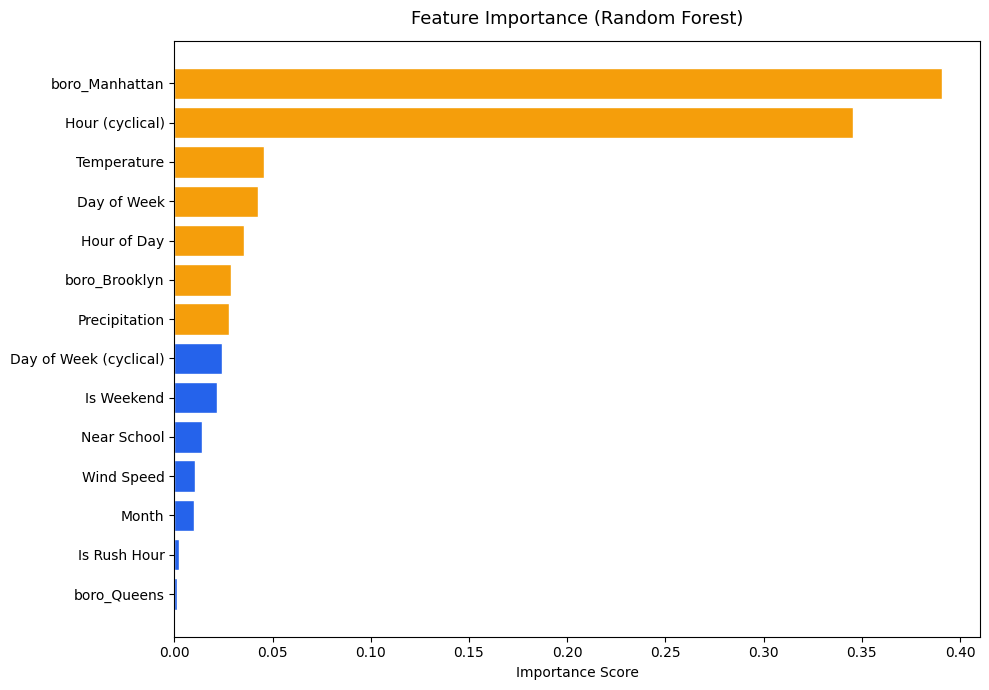

In [ ]:
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

importance_df['display_name'] = importance_df['feature'].map({
    'hour_sin': 'Hour (cyclical)',
    'hour_cos': 'Hour (cyclical)',
    'dow_sin': 'Day of Week (cyclical)',
    'dow_cos': 'Day of Week (cyclical)',
    'hour_of_day': 'Hour of Day',
    'day_of_week': 'Day of Week',
    'month': 'Month',
    'is_weekend': 'Is Weekend',
    'is_rush_hour': 'Is Rush Hour',
    'HourlyDryBulbTemperature': 'Temperature',
    'HourlyPrecipitation': 'Precipitation',
    'HourlyWindSpeed': 'Wind Speed',
    'near_school': 'Near School'
}).fillna(importance_df['feature'])

# aggregate cyclical pairs
importance_grouped = (importance_df.groupby('display_name')['importance']
                        .sum()
                        .sort_values(ascending=True)
                        .reset_index())

fig, ax = plt.subplots(figsize=(10, 7))
colors_imp = [COLORS['secondary'] if imp > importance_grouped['importance'].median()
            else COLORS['primary'] for imp in importance_grouped['importance']]
ax.barh(importance_grouped['display_name'], importance_grouped['importance'],
        color=colors_imp, edgecolor='white')
ax.set_title('Feature Importance (Random Forest)', fontsize=13, pad=12)
ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('../figures/model/feature_importance.png', bbox_inches='tight')
plt.show()


## 3.10: Spatial Residual Analysis

Prediction errors mapped geographically (overprediction and underprediction) concentrate the largest errors along the most traffic-dense areas in Manhattan. Reinforces the idea of the model poorly handling stations with higher-than-normal ridership counts, in comparison to low-variance outer stations, which are almost all white in the graphs.

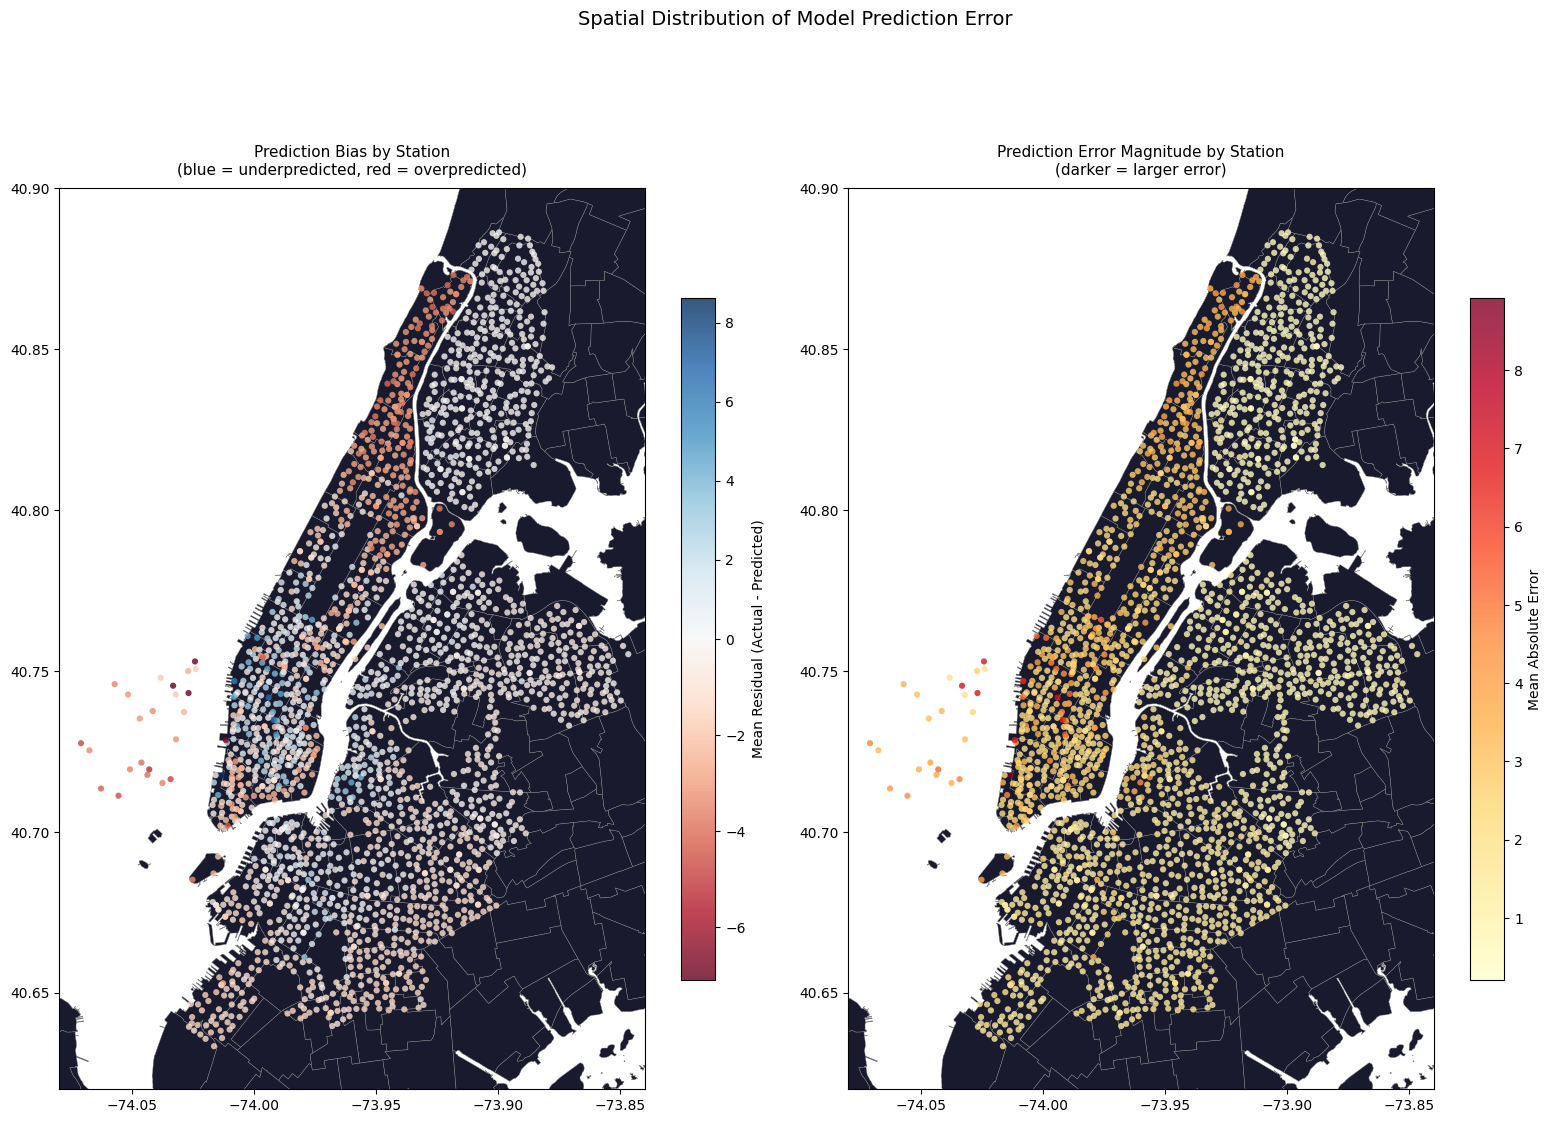

In [ ]:
station_residuals = (test_with_preds.groupby('start_station_id')
                        .agg(mean_residual=('residual', 'mean'),
                            abs_residual=('residual', lambda x: x.abs().mean()),
                            actual_mean=('ride_count', 'mean'),
                            predicted_mean=('predicted', 'mean'))
                        .reset_index())

# merge with station coordinates & build geodataframe
station_residuals = station_residuals.merge(
    station_lookup[['start_station_id', 'start_lat', 'start_lng', 'ntaname', 'boroname']],
    on='start_station_id', how='left'
)
residuals_geo = gpd.GeoDataFrame(
    station_residuals,
    geometry=gpd.points_from_xy(station_residuals['start_lng'], station_residuals['start_lat']),
    crs='EPSG:4326'
)
nta = gpd.read_file('../data/raw/spatial/nta.shp').to_crs('EPSG:4326')

fig, axes = plt.subplots(1, 2, figsize=(16, 12))

# plot left: mean residual per station (over vs under prediction)
nta.plot(ax=axes[0], color='#1a1a2e', edgecolor="#858585", linewidth=0.3)
divnorm = mcolors.TwoSlopeNorm(vmin=station_residuals['mean_residual'].min(), vcenter=0,
                            vmax=station_residuals['mean_residual'].max())

scatter0 = axes[0].scatter(
    residuals_geo['start_lng'],
    residuals_geo['start_lat'],
    c=residuals_geo['mean_residual'],
    cmap='RdBu',
    norm=divnorm,
    s=20, alpha=0.8, edgecolors='none'
)
plt.colorbar(scatter0, ax=axes[0], label='Mean Residual (Actual - Predicted)', shrink=0.6)
axes[0].set_title('Prediction Bias by Station\n(blue = underpredicted, red = overpredicted)',
                fontsize=11, pad=10)
axes[0].set_xlim(-74.08, -73.84)
axes[0].set_ylim(40.62, 40.90)

# plot right: absolute error per station (where model is least accurate)
nta.plot(ax=axes[1], color='#1a1a2e', edgecolor='#858585', linewidth=0.3)
scatter1 = axes[1].scatter(
    residuals_geo['start_lng'],
    residuals_geo['start_lat'],
    c=residuals_geo['abs_residual'],
    cmap='YlOrRd',
    s=20, alpha=0.8, edgecolors='none'
)
plt.colorbar(scatter1, ax=axes[1], label='Mean Absolute Error', shrink=0.6)
axes[1].set_title('Prediction Error Magnitude by Station\n(darker = larger error)',
                fontsize=11, pad=10)
axes[1].set_xlim(-74.08, -73.84)
axes[1].set_ylim(40.62, 40.90)

plt.suptitle('Spatial Distribution of Model Prediction Error', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/model/spatial_residuals.png', bbox_inches='tight')
plt.show()


We can look at the data a little closer and summarize the results by borough to see which boroughs the model handles best:

In [ ]:
print("Model Performance by Borough:")
borough_perf = (test_with_preds.merge(
        station_lookup[['start_station_id', 'boroname']],
        on='start_station_id', how='left')
    .groupby('boroname')
    .apply(lambda x: pd.Series({
        'rmse': np.sqrt(mean_squared_error(x['ride_count'], x['predicted'])),
        'r2': r2_score(x['ride_count'], x['predicted']),
        'mean_actual': x['ride_count'].mean()
	}))
    .round(3)
)
print(borough_perf)

Model Performance by Borough:
            rmse     r2  mean_actual
boroname                            
Bronx      0.735  0.005        1.334
Brooklyn   1.881  0.046        2.287
Manhattan  3.461  0.108        3.845
Queens     1.132  0.024        1.584


## 3.11: Rush Hour Model Performance

Some additional analysis on model performance during vs outside of rush hour. Otherwise similar, but likely offset slightly due to peak ridership periods during rush hour

In [ ]:
rush_test = test_with_preds[test_with_preds['is_rush_hour'] == 1]
nonrush_test = test_with_preds[test_with_preds['is_rush_hour'] == 0]

rush_r2 = r2_score(rush_test['ride_count'], rush_test['predicted'])
nonrush_r2 = r2_score(nonrush_test['ride_count'], nonrush_test['predicted'])
rush_rmse = np.sqrt(mean_squared_error(rush_test['ride_count'], rush_test['predicted']))
nonrush_rmse = np.sqrt(mean_squared_error(nonrush_test['ride_count'], nonrush_test['predicted']))

print(f"Rush hour model performance:")
print(f"Rush hour R2: {rush_r2:.3f}, RMSE: {rush_rmse:.3f}")
print(f"Non-rush hour R2: {nonrush_r2:.3f}, RMSE: {nonrush_rmse:.3f}")

Rush hour model performance:
Rush hour R2: 0.182, RMSE: 3.296
Non-rush hour R2: 0.162, RMSE: 2.174


To summarize the results we got in this section:

In [ ]:
print("Model Summary (Best Model = Random Forest):")
print(f"Train size: {len(train):,} rows")
print(f"Test size: {len(test):,} rows")
print(f"Number of features: {len(feature_cols)}\n")
print(f"Test R2: {rf_stats['r2']:.3f}")
print(f"Test RMSE: {rf_stats['rmse']:.3f} rides per station per hour")
print(f"Test MAE: {rf_stats['mae']:.3f} rides per station per hour")
print(f"Improvement over baseline RMSE: {((baseline_rmse - rf_stats['rmse'])/baseline_rmse*100):.2f}%")

Model Summary (Best Model = Random Forest):
Train size: 1,180,227 rows
Test size: 582,685 rows
Number of features: 16

Test R2: 0.194
Test RMSE: 2.666 rides per station per hour
Test MAE: 1.761 rides per station per hour
Improvement over baseline RMSE: 10.54%
